In [ ]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ============================
# CONFIGURATION
# ============================
AF_OUTPUT_DIR = # provide path to 3D complexes generated by AlphaFold3"
SAVE_DIR = "./plddts"
SAVE_DIR = "./plddts_diffdock"
os.makedirs(SAVE_DIR, exist_ok=True)

all_atom_plddt = []
all_residue_plddt = []
model_summary = []

In [2]:
json_files = glob.glob(os.path.join(AF_OUTPUT_DIR, "**/seed-1_sample-0/confidences.json"), recursive=True)
len(json_files)

3230

In [ ]:
import os
import glob
import json
import numpy as np
import pandas as pd
from tqdm import tqdm


all_atom_plddt = []
all_residue_plddt = []
model_summary = []


def compute_residue_plddt(data):
    atom_plddts = np.array(data["atom_plddts"])
    atom_chain_ids = np.array(data["atom_chain_ids"])

    token_chain_ids = np.array(data["token_chain_ids"])
    token_res_ids = np.array(data["token_res_ids"])

    # Number of residues
    n_res = len(token_res_ids)

    # Approximate mapping:
    # Divide atoms evenly per residue based on count per chain
    residue_scores = []

    atom_index = 0

    for chain, res_id in zip(token_chain_ids, token_res_ids):
        # Count how many atoms belong to this residue
        # based on consecutive atom_chain_ids matching
        count = 0
        while atom_index + count < len(atom_chain_ids) and \
              atom_chain_ids[atom_index + count] == chain:
            count += 1

        if count == 0:
            continue

        residue_mean = np.mean(atom_plddts[atom_index:atom_index + count])
        residue_scores.append(residue_mean)

        atom_index += count

    return np.array(residue_scores), atom_plddts



for jf in tqdm(json_files):
    try:
        with open(jf, "r") as f:
            data = json.load(f)

        residue_scores, atom_scores = compute_residue_plddt(data)

        all_atom_plddt.extend(atom_scores)
        all_residue_plddt.extend(residue_scores)

        model_summary.append({
            "model": os.path.basename(jf),
            "mean_atom_plddt": np.mean(atom_scores),
            "mean_residue_plddt": np.mean(residue_scores),
            "pct_res_gt90": np.mean(residue_scores > 90) * 100,
            "pct_res_gt70": np.mean(residue_scores > 70) * 100,
            "pct_res_lt50": np.mean(residue_scores < 50) * 100,
            "n_atoms": len(atom_scores),
            "n_residues": len(residue_scores)
        })

    except Exception as e:
        print("Error:", jf, e)


df = pd.DataFrame(model_summary)
df.to_csv(os.path.join(SAVE_DIR, "per_model_summary.csv"), index=False)

print("Done.")


In [4]:


sns.set(style="whitegrid")

all_atom_plddt = []
all_model_means = []

# =============================
# LOOP THROUGH JSON FILES
# =============================
for jf in tqdm(json_files):
    try:
        with open(jf, "r") as f:
            data = json.load(f)

        atom_plddts = np.array(data["atom_plddts"])

        all_atom_plddt.extend(atom_plddts)
        all_model_means.append(np.mean(atom_plddts))

    except Exception as e:
        print("Error:", jf, e)

all_atom_plddt = np.array(all_atom_plddt)
all_model_means = np.array(all_model_means)

print("Total models:", len(all_model_means))
print("Global mean pLDDT:", np.mean(all_atom_plddt))



100%|██████████| 3230/3230 [02:27<00:00, 21.94it/s]


Total models: 3230
Global mean pLDDT: 77.56604579199659


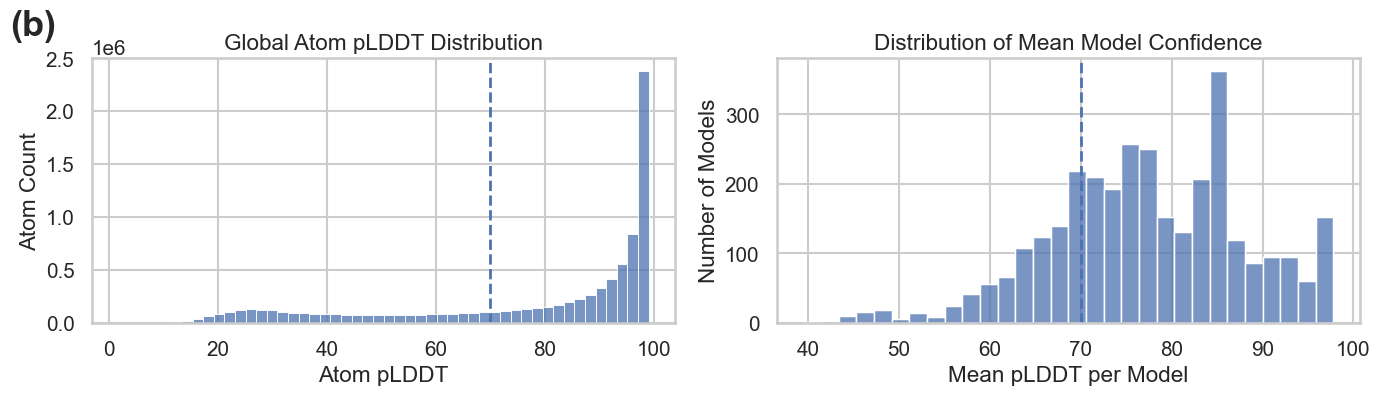

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk", font_scale=.90)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ====================================================
# 1️⃣ GLOBAL ATOM pLDDT DISTRIBUTION
# ====================================================
sns.histplot(all_atom_plddt, bins=50, ax=axes[0])
axes[0].axvline(70, linestyle='--', linewidth=2)
axes[0].set_xlabel("Atom pLDDT")
axes[0].set_ylabel("Atom Count")
axes[0].set_title("Global Atom pLDDT Distribution")

# ====================================================
# 2️⃣ PER-MODEL MEAN pLDDT DISTRIBUTION
# ====================================================
sns.histplot(all_model_means, bins=30, ax=axes[1])
axes[1].axvline(70, linestyle='--', linewidth=2)
axes[1].set_xlabel("Mean pLDDT per Model")
axes[1].set_ylabel("Number of Models")
axes[1].set_title("Distribution of Mean Model Confidence")

fig.text(
    0.01, 1.0, "(b)",
    fontsize=26,
    fontweight="bold",
    va="top",
    ha="left"
)

plt.tight_layout()
plt.show()

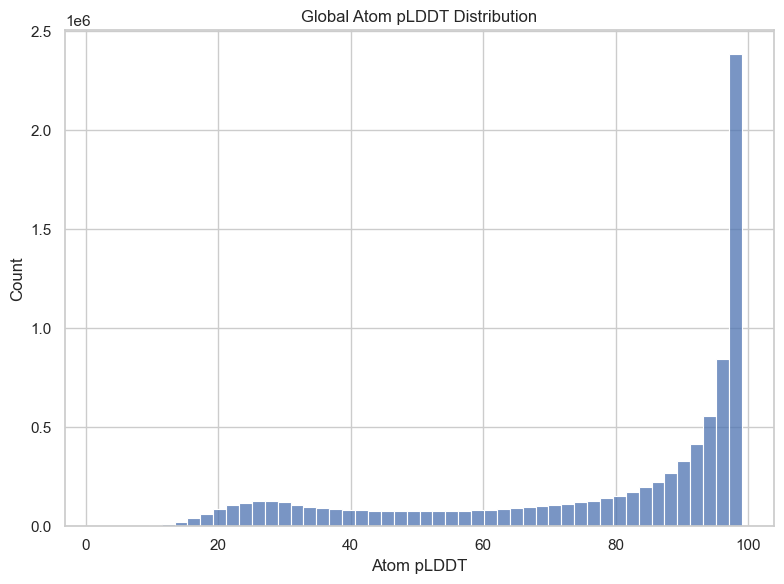

In [ ]:
# ====================================================
# 1️⃣ GLOBAL ATOM pLDDT DISTRIBUTION
# ====================================================
plt.figure(figsize=(8,6))
sns.histplot(all_atom_plddt, bins=50)
plt.xlabel("Atom pLDDT")
plt.ylabel("Count")
plt.title("Global Atom pLDDT Distribution")
plt.tight_layout()

# ====================================================
# 2️⃣ PER-MODEL MEAN pLDDT DISTRIBUTION
# ====================================================
plt.figure(figsize=(8,6))
sns.histplot(all_model_means, bins=30)
plt.xlabel("Mean Atom pLDDT per Model")
plt.ylabel("Number of Models")
plt.title("Distribution of Mean Model Confidence")
plt.tight_layout()

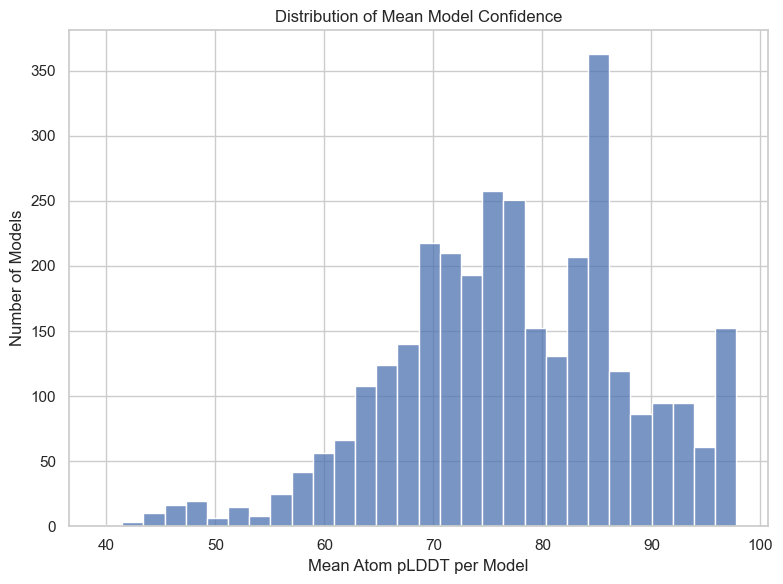

In [12]:
# ====================================================
# 2️⃣ PER-MODEL MEAN pLDDT DISTRIBUTION
# ====================================================
plt.figure(figsize=(8,6))
sns.histplot(all_model_means, bins=30)
plt.xlabel("Mean Atom pLDDT per Model")
plt.ylabel("Number of Models")
plt.title("Distribution of Mean Model Confidence")
plt.tight_layout()

In [ ]:


plt.savefig(os.path.join(SAVE_DIR, "global_atom_plddt_distribution.png"), dpi=300)
plt.close()


# ====================================================
# 2️⃣ PER-MODEL MEAN pLDDT DISTRIBUTION
# ====================================================
plt.figure(figsize=(8,6))
sns.histplot(all_model_means, bins=30)
plt.xlabel("Mean Atom pLDDT per Model")
plt.ylabel("Number of Models")
plt.title("Distribution of Mean Model Confidence")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "mean_plddt_per_model.png"), dpi=300)
plt.close()


# ====================================================
# 3️⃣ BOXPLOT OF MODEL CONFIDENCE
# ====================================================
plt.figure(figsize=(6,6))
sns.boxplot(x=all_model_means)
plt.xlabel("Mean Atom pLDDT per Model")
plt.title("Model Confidence Boxplot")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "boxplot_model_confidence.png"), dpi=300)
plt.close()


# ====================================================
# 4️⃣ CONFIDENCE CATEGORY BAR PLOT
# ====================================================
very_high = np.sum(all_atom_plddt > 90)
confident = np.sum((all_atom_plddt > 70) & (all_atom_plddt <= 90))
low = np.sum((all_atom_plddt > 50) & (all_atom_plddt <= 70))
very_low = np.sum(all_atom_plddt <= 50)

categories = ["Very High (>90)", "Confident (70–90)", "Low (50–70)", "Very Low (<50)"]
counts = [very_high, confident, low, very_low]

plt.figure(figsize=(8,6))
sns.barplot(x=categories, y=counts)
plt.xticks(rotation=45)
plt.ylabel("Number of Atoms")
plt.title("pLDDT Confidence Categories")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confidence_categories.png"), dpi=300)
plt.close()

print("All plots saved in:", SAVE_DIR)
